# **Reconhecimento de Emoções em Faces**
## **Nome - NUSP:**
- Gustavo Cardozo De Moraes Moreira - 5244057
- Francisco Luiz Maian do Nascimento - 14570890

---

## Estrutura do Trabalho
**1. Setup & Dataset**: Carregamento do FER2013 e exploração dos dados

**2. Baseline — CNN**: CNN treinada do zero

**3. Modelo Final — Fine-tuning ResNet-18**

**4. Comparação de Resultados**: Métricas, confusion matrix e curvas |


---
## Seção 1 — Setup & Dataset

In [2]:

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time, copy, os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torchvision import transforms, models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')


Dispositivo: cuda


In [3]:
import kagglehub

path = kagglehub.dataset_download('nicolejyt/facialexpressionrecognition')
df = pd.read_csv(path + '/fer2013.csv')
print(df.shape)
df.head()


Using Colab cache for faster access to the 'facialexpressionrecognition' dataset.
(35887, 3)


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


### 1.1 Divisão Treino / Teste

In [4]:
train_df = df[df['Usage'] == 'Training'].drop(columns=['Usage'])
test_df  = df[df['Usage'] != 'Training'].drop(columns=['Usage'])

def pixels_to_array(df_):
    X = np.array([np.fromstring(p, sep=' ', dtype=np.uint8).reshape(48, 48)
                  for p in df_['pixels']])
    y = df_['emotion'].values
    return X, y

X_train, y_train = pixels_to_array(train_df)
X_test,  y_test  = pixels_to_array(test_df)

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

emotion_dict = {0:'Angry', 1:'Disgust', 2:'Fear',
                3:'Happy', 4:'Sad', 5:'Surprise', 6:'Neutral'}
EMOTIONS = [emotion_dict[i] for i in range(7)]


Treino: (28709, 48, 48) | Teste: (7178, 48, 48)


### 1.2 Exploração Visual

/tmp/ipykernel_1290/2012387109.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='emotion', data=df_visu,


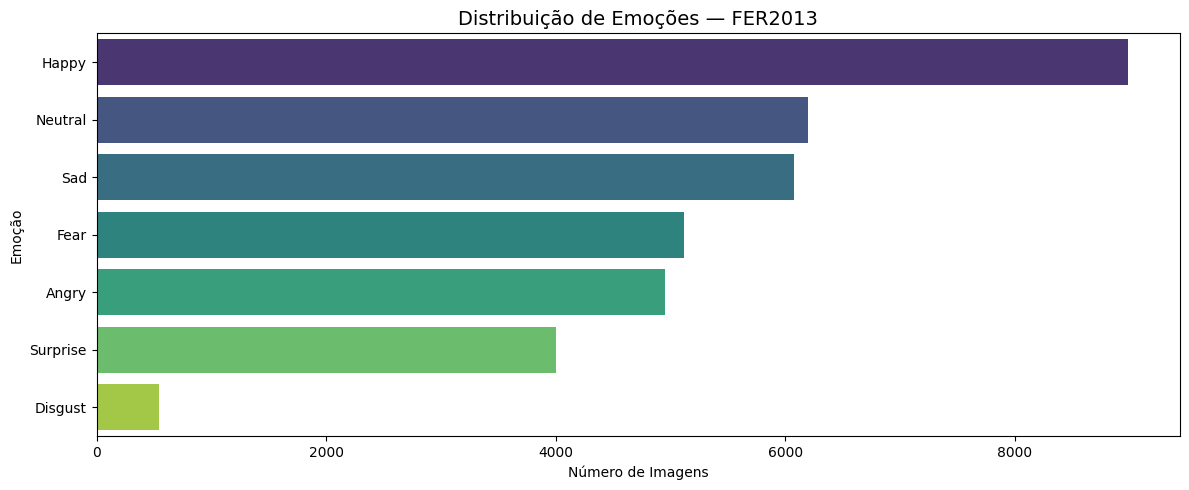

In [5]:
# Distribuição de classes
df_visu = df.copy()
df_visu['emotion'] = df_visu['emotion'].map(emotion_dict)

plt.figure(figsize=(12, 5))
sns.countplot(y='emotion', data=df_visu,
              order=df_visu['emotion'].value_counts().index, palette='viridis')
plt.title('Distribuição de Emoções — FER2013', fontsize=14)
plt.xlabel('Número de Imagens')
plt.ylabel('Emoção')
plt.tight_layout()
plt.show()


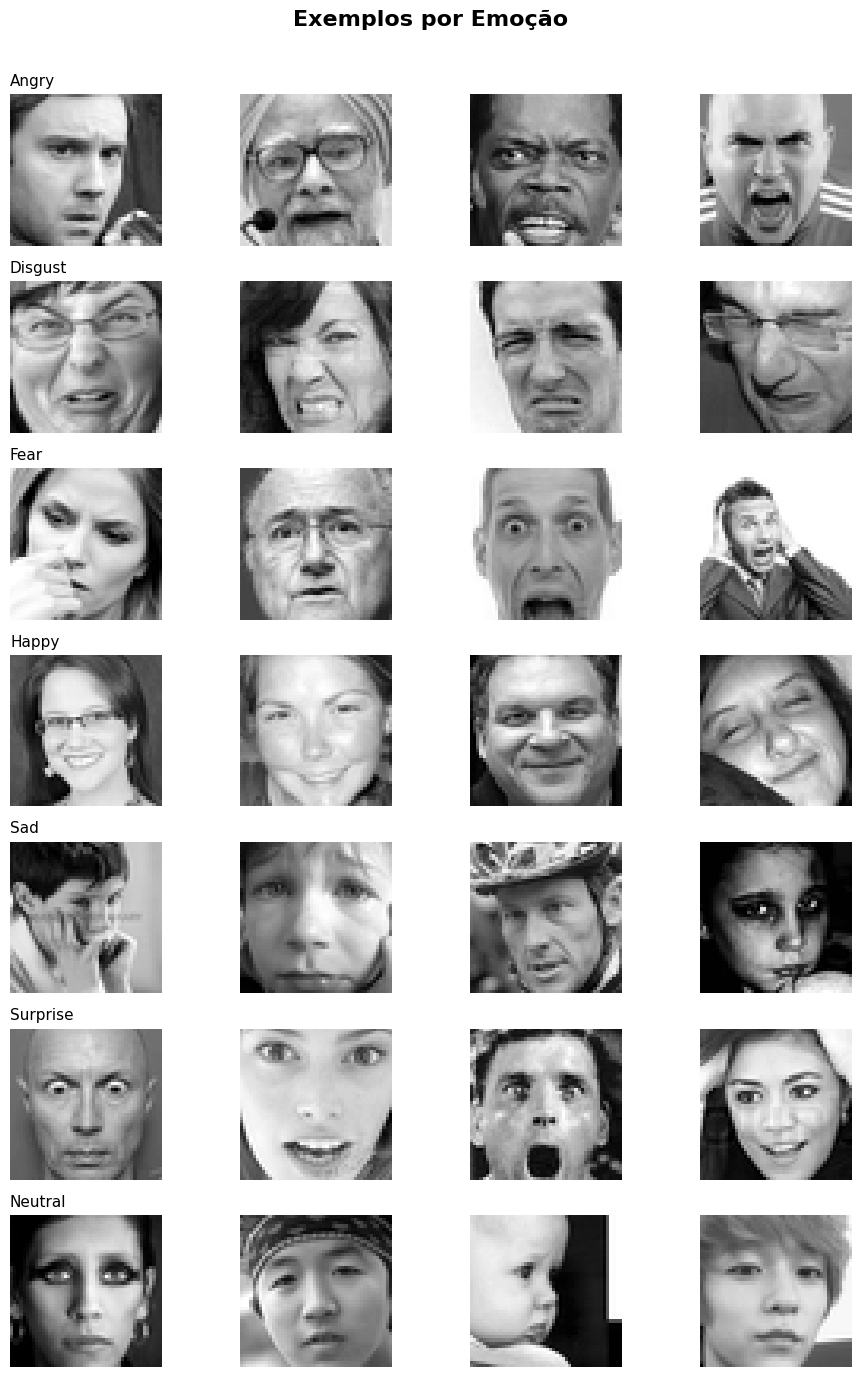

In [6]:
# Exemplos por emoção
fig, axes = plt.subplots(7, 4, figsize=(10, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.1)

for eid in range(7):
    subset = df[df['emotion'] == eid].head(4)
    for i, (_, row) in enumerate(subset.iterrows()):
        px = np.fromstring(row['pixels'], sep=' ', dtype=np.uint8).reshape(48, 48)
        ax = axes[eid, i]
        ax.imshow(px, cmap='gray')
        ax.axis('off')
        if i == 0:
            ax.set_title(emotion_dict[eid], fontsize=11, loc='left', color='black')

fig.suptitle('Exemplos por Emoção', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


---
## Seção 2 — Baseline: CNN

Modelo treinado **do zero** com 4 blocos Conv → ReLU → MaxPool.
Serve como referência (baseline) para comparar com o fine-tuning.


### 2.1 Dataset & Transforms

In [7]:
class NumpyDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X, self.y, self.transform = X, y, transform

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        img = Image.fromarray(self.X[idx], mode='L')
        if self.transform: img = self.transform(img)
        return img, int(self.y[idx])


tf_train_baseline = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(48, scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
tf_test_baseline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds_b = NumpyDataset(X_train, y_train, tf_train_baseline)
test_ds_b  = NumpyDataset(X_test,  y_test,  tf_test_baseline)
train_dl_b = DataLoader(train_ds_b, batch_size=64, shuffle=True,  num_workers=0)
test_dl_b  = DataLoader(test_ds_b,  batch_size=64, shuffle=False, num_workers=0)


### 2.2 Arquitetura CNN

In [8]:
class CNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),  # 24x24
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 12x12
            nn.Conv2d(64,128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 6x6
            nn.Conv2d(128,256,3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 3x3
        )
        self.classifier = nn.Sequential(
            nn.Linear(256*3*3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

baseline_model = CNN().to(device)
print(f'Parâmetros (CNN): {count_params(baseline_model):,}')


Parâmetros (CNN): 979,719


### 2.3 Treinamento Baseline

In [9]:
def get_class_weights(y):
    counts = np.bincount(y)
    w = len(y) / (len(counts) * counts)
    return torch.tensor(w, dtype=torch.float32).to(device)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += out.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), 100 * correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        preds = out.argmax(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return 100 * correct / total, np.array(all_preds), np.array(all_labels)


cw_b = get_class_weights(y_train)
criterion_b  = nn.CrossEntropyLoss(weight=cw_b)
optimizer_b  = optim.Adam(baseline_model.parameters(), lr=1e-3)
scheduler_b  = optim.lr_scheduler.StepLR(optimizer_b, step_size=15, gamma=0.5)

EPOCHS_BASELINE = 30
history_b = {'loss': [], 'acc': []}

print('Treinando Baseline CNN...')
t0 = time.time()
for epoch in range(1, EPOCHS_BASELINE + 1):
    loss, acc = train_epoch(baseline_model, train_dl_b, criterion_b, optimizer_b)
    scheduler_b.step()
    history_b['loss'].append(loss)
    history_b['acc'].append(acc)
    if epoch % 10 == 0:
        val_acc, _, _ = evaluate(baseline_model, test_dl_b)
        print(f'  Época {epoch:02d}/{EPOCHS_BASELINE} | Loss: {loss:.4f} | '
              f'Train Acc: {acc:.1f}% | Val Acc: {val_acc:.1f}%')

print(f'\nTempo total: {time.time()-t0:.0f}s')


Treinando Baseline CNN...


/tmp/ipykernel_1290/1036475595.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.X[idx], mode='L')


  Época 10/30 | Loss: 1.3267 | Train Acc: 48.8% | Val Acc: 51.0%
  Época 20/30 | Loss: 1.1569 | Train Acc: 54.1% | Val Acc: 55.5%
  Época 30/30 | Loss: 1.0932 | Train Acc: 56.2% | Val Acc: 57.4%

Tempo total: 655s


In [10]:
baseline_acc, baseline_preds, baseline_labels = evaluate(baseline_model, test_dl_b)
print(f'\n=== Acurácia Baseline (Teste) === {baseline_acc:.2f}%')
print('\nRelatório por classe:')
print(classification_report(baseline_labels, baseline_preds, target_names=EMOTIONS))


/tmp/ipykernel_1290/1036475595.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.X[idx], mode='L')



=== Acurácia Baseline (Teste) === 57.44%

Relatório por classe:
              precision    recall  f1-score   support

       Angry       0.47      0.52      0.49       958
     Disgust       0.33      0.68      0.45       111
        Fear       0.43      0.24      0.31      1024
       Happy       0.84      0.75      0.79      1774
         Sad       0.42      0.51      0.46      1247
    Surprise       0.71      0.78      0.75       831
     Neutral       0.53      0.56      0.54      1233

    accuracy                           0.57      7178
   macro avg       0.53      0.58      0.54      7178
weighted avg       0.58      0.57      0.57      7178



In [11]:
# Salva o modelo baseline
torch.save(baseline_model.state_dict(), 'baseline_cnn.pth')
print('Modelo baseline salvo em baseline_simplecnn.pth')


Modelo baseline salvo em baseline_simplecnn.pth


---
## Seção 3 — Modelo Final: Fine-tuning ResNet-18

Utilizamos uma **ResNet-18 pré-treinada no ImageNet** e adaptamos para classificação de emoções.

### Estratégia de Fine-tuning em 2 fases

**1 — Feature Extraction**

**2 — Fine-tuning completo**

Imagens grayscale (1 canal) são convertidas para RGB (3 canais) com `transforms.Lambda`,
e redimensionadas para 224×224 para compatibilidade com a ResNet.


### 3.1 Transforms para ResNet

In [12]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Grayscale → RGB → resize 224 (padrão ImageNet)
tf_train_ft = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),   # L → RGB
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

tf_test_ft = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_ds_ft = NumpyDataset(X_train, y_train, tf_train_ft)
test_ds_ft  = NumpyDataset(X_test,  y_test,  tf_test_ft)
train_dl_ft = DataLoader(train_ds_ft, batch_size=64, shuffle=True,  num_workers=0)
test_dl_ft  = DataLoader(test_ds_ft,  batch_size=64, shuffle=False, num_workers=0)


### 3.2 Modelo ResNet-18 adaptado

In [13]:
def build_resnet18_fer(num_classes=7, freeze_backbone=True):
    """ResNet-18 pré-treinada com head substituído para FER."""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Substitui a camada final
    in_features = model.fc.in_features   # 512
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model


ft_model = build_resnet18_fer(freeze_backbone=True).to(device)
print(f'Parâmetros treináveis (Fase 1): {count_params(ft_model):,}')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


Parâmetros treináveis (Fase 1): 133,127


### 3.3 Fase 1 — Feature Extraction (backbone congelado)

In [17]:
cw_ft = get_class_weights(y_train)
criterion_ft = nn.CrossEntropyLoss(weight=cw_ft)

# Apenas os parâmetros do novo head
optimizer_ft1 = optim.Adam(
    filter(lambda p: p.requires_grad, ft_model.parameters()), lr=1e-3
)

EPOCHS_PHASE1 = 10
history_ft1 = {'loss': [], 'acc': [], 'val_acc': []}

print('─── Fase 1: Feature Extraction ───')
for epoch in range(1, EPOCHS_PHASE1 + 1):
    loss, acc = train_epoch(ft_model, train_dl_ft, criterion_ft, optimizer_ft1)
    val_acc, _, _ = evaluate(ft_model, test_dl_ft)
    history_ft1['loss'].append(loss)
    history_ft1['acc'].append(acc)
    history_ft1['val_acc'].append(val_acc)
    print(f'  Época {epoch:02d}/{EPOCHS_PHASE1} | Loss: {loss:.4f} | '
              f'Train: {acc:.1f}% | Val: {val_acc:.1f}%')


─── Fase 1: Feature Extraction ───


/tmp/ipykernel_1290/1036475595.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.X[idx], mode='L')


  Época 01/10 | Loss: 1.6759 | Train: 35.0% | Val: 40.2%
  Época 02/10 | Loss: 1.6624 | Train: 35.1% | Val: 40.1%
  Época 03/10 | Loss: 1.6485 | Train: 35.9% | Val: 40.5%
  Época 04/10 | Loss: 1.6506 | Train: 35.1% | Val: 39.8%
  Época 05/10 | Loss: 1.6516 | Train: 35.8% | Val: 36.6%
  Época 06/10 | Loss: 1.6469 | Train: 35.6% | Val: 38.8%
  Época 07/10 | Loss: 1.6390 | Train: 36.0% | Val: 34.1%
  Época 08/10 | Loss: 1.6233 | Train: 36.2% | Val: 40.8%
  Época 09/10 | Loss: 1.6328 | Train: 36.0% | Val: 39.8%
  Época 10/10 | Loss: 1.6506 | Train: 35.8% | Val: 38.4%


### 3.4 Fase 2 — Fine-tuning completo (backbone descongelado)

In [18]:
# Descongela todo o modelo
for param in ft_model.parameters():
    param.requires_grad = True

print(f'Parâmetros treináveis (Fase 2): {count_params(ft_model):,}')

# LR diferenciado: backbone menor, head maior
backbone_params = [p for n, p in ft_model.named_parameters() if 'fc' not in n]
head_params     = [p for n, p in ft_model.named_parameters() if 'fc'     in n]

optimizer_ft2 = optim.Adam([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params,     'lr': 1e-4}
])
scheduler_ft2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft2, T_max=30)

EPOCHS_PHASE2 = 30
history_ft2 = {'loss': [], 'acc': [], 'val_acc': []}
best_val, best_weights = 0, None

print('─── Fase 2: Fine-tuning Completo ───')
for epoch in range(1, EPOCHS_PHASE2 + 1):
    loss, acc = train_epoch(ft_model, train_dl_ft, criterion_ft, optimizer_ft2)
    val_acc, _, _ = evaluate(ft_model, test_dl_ft)
    scheduler_ft2.step()
    history_ft2['loss'].append(loss)
    history_ft2['acc'].append(acc)
    history_ft2['val_acc'].append(val_acc)
    # Salva o melhor modelo
    if val_acc > best_val:
        best_val = val_acc
        best_weights = copy.deepcopy(ft_model.state_dict())
    if epoch % 5 == 0:
        print(f'  Época {epoch:02d}/{EPOCHS_PHASE2} | Loss: {loss:.4f} | '
              f'Train: {acc:.1f}% | Val: {val_acc:.1f}% | Best: {best_val:.1f}%')

# Restaura melhor modelo
ft_model.load_state_dict(best_weights)
print(f'\nMelhor validação: {best_val:.2f}%')


Parâmetros treináveis (Fase 2): 11,309,639
─── Fase 2: Fine-tuning Completo ───


/tmp/ipykernel_1290/1036475595.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.X[idx], mode='L')


  Época 05/30 | Loss: 1.1740 | Train: 54.6% | Val: 56.4% | Best: 56.4%
  Época 10/30 | Loss: 1.0113 | Train: 60.3% | Val: 60.7% | Best: 60.7%
  Época 15/30 | Loss: 0.9032 | Train: 63.9% | Val: 62.4% | Best: 62.4%
  Época 20/30 | Loss: 0.8531 | Train: 66.0% | Val: 63.4% | Best: 63.9%
  Época 25/30 | Loss: 0.8198 | Train: 67.0% | Val: 64.3% | Best: 64.4%
  Época 30/30 | Loss: 0.8183 | Train: 66.9% | Val: 64.6% | Best: 64.6%

Melhor validação: 64.60%


In [19]:
ft_acc, ft_preds, ft_labels = evaluate(ft_model, test_dl_ft)
print(f'=== Acurácia ResNet-18 Fine-tuned (Teste) === {ft_acc:.2f}%')
print('\nRelatório por classe:')
print(classification_report(ft_labels, ft_preds, target_names=EMOTIONS))

# Salva o melhor modelo
torch.save(ft_model.state_dict(), 'resnet18_fer_finetuned.pth')
print('\nModelo salvo em resnet18_fer_finetuned.pth')


/tmp/ipykernel_1290/1036475595.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.X[idx], mode='L')


=== Acurácia ResNet-18 Fine-tuned (Teste) === 64.60%

Relatório por classe:
              precision    recall  f1-score   support

       Angry       0.56      0.61      0.58       958
     Disgust       0.57      0.70      0.63       111
        Fear       0.51      0.33      0.40      1024
       Happy       0.87      0.86      0.86      1774
         Sad       0.50      0.51      0.51      1247
    Surprise       0.73      0.81      0.77       831
     Neutral       0.58      0.65      0.62      1233

    accuracy                           0.65      7178
   macro avg       0.62      0.64      0.62      7178
weighted avg       0.64      0.65      0.64      7178


Modelo salvo em resnet18_fer_finetuned.pth


---
## Seção 4 — Comparação: Baseline vs Fine-tuning


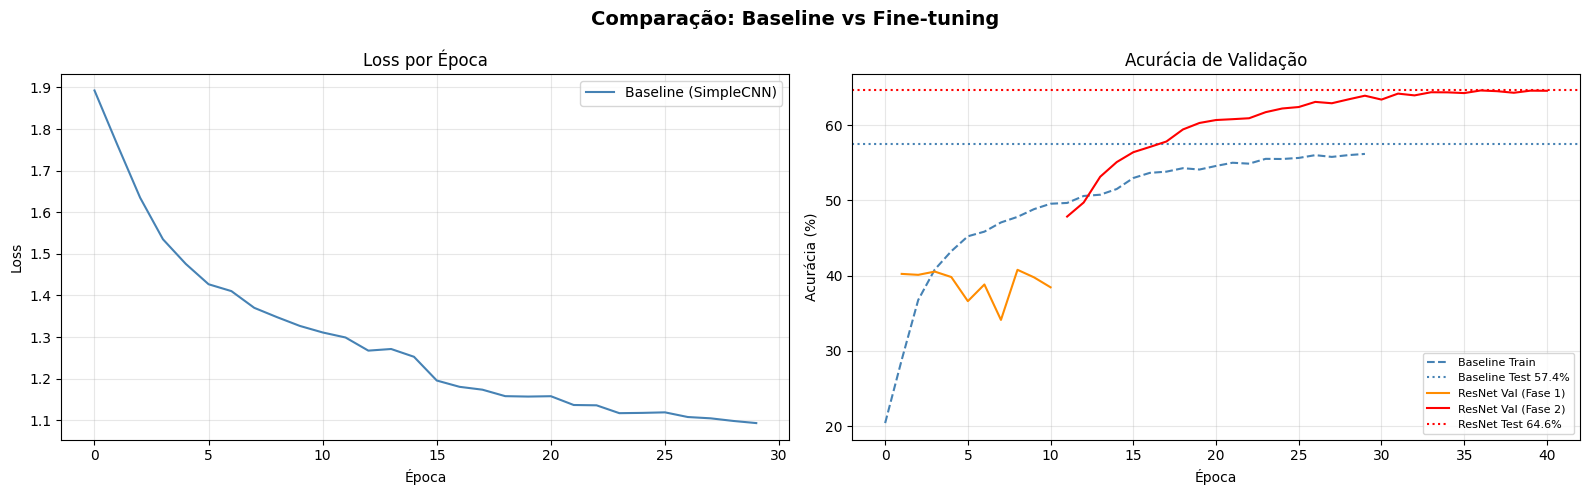

In [20]:
# ── Curvas de aprendizado ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss do Baseline
ax = axes[0]
ax.plot(history_b['loss'], label='Baseline (SimpleCNN)', color='steelblue')
ax.set_title('Loss por Época')
ax.set_xlabel('Época'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# Acurácia Fine-tuning (Fases 1 + 2)
ax = axes[1]
ep1 = list(range(1, EPOCHS_PHASE1 + 1))
ep2 = list(range(EPOCHS_PHASE1 + 1, EPOCHS_PHASE1 + EPOCHS_PHASE2 + 1))
val_all = history_ft1['val_acc'] + history_ft2['val_acc']
ax.plot(history_b['acc'], label='Baseline Train', color='steelblue', linestyle='--')
ax.axhline(baseline_acc, color='steelblue', linestyle=':', label=f'Baseline Test {baseline_acc:.1f}%')
ax.plot(ep1, history_ft1['val_acc'], color='darkorange', linestyle='-', label='ResNet Val (Fase 1)')
ax.plot(ep2, history_ft2['val_acc'], color='red',        linestyle='-', label='ResNet Val (Fase 2)')
ax.axhline(ft_acc, color='red', linestyle=':', label=f'ResNet Test {ft_acc:.1f}%')
ax.set_title('Acurácia de Validação')
ax.set_xlabel('Época'); ax.set_ylabel('Acurácia (%)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Comparação: Baseline vs Fine-tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


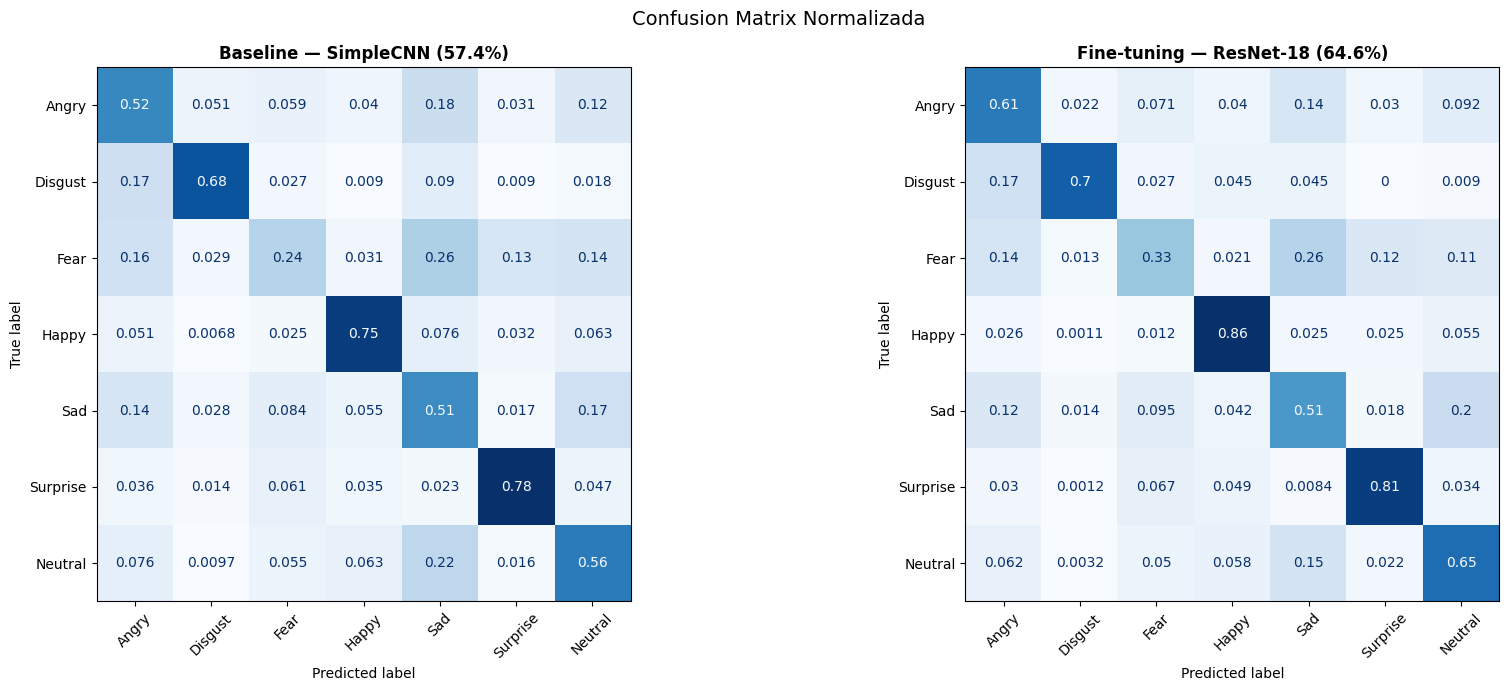

In [21]:
# ── Confusion Matrices lado a lado ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, preds, labels, title in [
    (axes[0], baseline_preds, baseline_labels, f'Baseline — SimpleCNN ({baseline_acc:.1f}%)'),
    (axes[1], ft_preds,       ft_labels,       f'Fine-tuning — ResNet-18 ({ft_acc:.1f}%)')
]:
    cm = confusion_matrix(labels, preds, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=EMOTIONS)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix Normalizada', fontsize=14)
plt.tight_layout()
plt.show()


In [22]:
# ── Tabela resumo ─────────────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

def summary_metrics(labels, preds, name):
    return {
        'Modelo': name,
        'Acurácia (%)': f'{100*np.mean(labels==preds):.2f}',
        'F1-macro': f'{f1_score(labels, preds, average="macro"):.4f}',
        'Precision-macro': f'{precision_score(labels, preds, average="macro"):.4f}',
        'Recall-macro': f'{recall_score(labels, preds, average="macro"):.4f}',
    }

df_summary = pd.DataFrame([
    summary_metrics(baseline_labels, baseline_preds, 'SimpleCNN (Baseline)'),
    summary_metrics(ft_labels,       ft_preds,       'ResNet-18 Fine-tuned'),
])
df_summary.set_index('Modelo', inplace=True)
print('=== Resumo de Métricas ===')
df_summary


=== Resumo de Métricas ===


,Acurácia (%),F1-macro,Precision-macro,Recall-macro
Modelo,,,,
SimpleCNN (Baseline),57.44,0.5415,0.5333,0.5769
ResNet-18 Fine-tuned,64.60,0.6238,0.6172,0.6392
